# Metals Intraday Flow: Extreme Impact Decay and Session Reversal

This notebook tests two higher-turnover metal futures strategy ideas on the 12-month Databento trade sample:

1. **Extreme Flow Impact Decay**: after a large signed-flow bar that moves price in the same direction, test continuation vs fade over short intraday horizons.
2. **Session Window Flow Reversal**: after a session window with aligned flow and price pressure, fade the move over the next intraday horizon.

The key implementation detail is that root-level trade files contain many contract months. The notebook first maps each root to the **daily most-active contract** and builds returns only from that active contract, which avoids synthetic cross-contract price jumps.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

In [2]:
TRADE_DIR = Path("/home/famadeo/research/databento-asset-browser/data/metals_trades_12m/outright")
CACHE_DIR = Path("../../data/features/metals_intraday_flow_active_contract_5m").resolve()
CACHE_DIR.mkdir(parents=True, exist_ok=True)

ROOTS = ["GC", "SI", "HG", "PL", "PA"]
ROUND_TRIP_COST_BPS = {"GC": 3.0, "SI": 3.0, "HG": 3.0, "PL": 4.0, "PA": 6.0}
FREQ = "5m"
LOOKBACK_5M_BARS = 20 * 24 * 12
HORIZONS_5M = [1, 3, 6, 12, 24]
DAYS_PER_SAMPLE = 365.0

WINDOWS = [
    ("asia_late", 0, 7 * 60),
    ("europe_open", 7 * 60, 10 * 60),
    ("pre_us", 10 * 60, 13 * 60 + 30),
    ("us_open_30", 13 * 60 + 30, 14 * 60),
    ("us_open_60", 13 * 60 + 30, 14 * 60 + 30),
    ("us_midday", 14 * 60 + 30, 17 * 60 + 30),
    ("settle_zone", 17 * 60 + 30, 18 * 60 + 30),
    ("late_us", 18 * 60 + 30, 21 * 60),
]

## Active-Contract 5-Minute Bars

`side == 'B'` is buyer-initiated, `side == 'A'` is seller-initiated, and `side == 'N'` is treated as unsigned. Unsigned trades still contribute to volume, but not to OFI.

In [3]:
def active_contract_bars(root: str, force: bool = False) -> pd.DataFrame:
    cache_path = CACHE_DIR / f"{root}_active_contract_5m.parquet"
    if cache_path.exists() and not force:
        df = pd.read_parquet(cache_path)
        df.index = pd.to_datetime(df.index, utc=True)
        return df

    path = TRADE_DIR / f"{root}.parquet"
    lf = (
        pl.scan_parquet(str(path))
        .select(["ts_event", "symbol", "price", "size", "side"])
        .with_columns(pl.col("ts_event").dt.date().alias("date"))
    )
    active = (
        lf.group_by(["date", "symbol"])
        .agg(pl.col("size").sum().alias("day_volume"))
        .sort(["date", "day_volume"], descending=[False, True])
        .unique("date", keep="first")
        .select(["date", pl.col("symbol").alias("active_symbol")])
    )
    active_trades = (
        lf.join(active, on="date", how="inner")
        .filter(pl.col("symbol") == pl.col("active_symbol"))
        .drop("active_symbol")
    )

    q95 = active_trades.select(pl.col("size").quantile(0.95)).collect().item()
    q99 = active_trades.select(pl.col("size").quantile(0.99)).collect().item()

    bars = (
        active_trades.with_columns(
            [
                pl.col("ts_event").dt.truncate(FREQ).alias("ts"),
                pl.when(pl.col("side") == "B")
                .then(pl.col("size"))
                .when(pl.col("side") == "A")
                .then(-pl.col("size"))
                .otherwise(0)
                .alias("signed_size"),
                pl.when((pl.col("side") == "B") & (pl.col("size") >= q95))
                .then(pl.col("size"))
                .when((pl.col("side") == "A") & (pl.col("size") >= q95))
                .then(-pl.col("size"))
                .otherwise(0)
                .alias("signed_size_q95"),
                pl.when((pl.col("side") == "B") & (pl.col("size") >= q99))
                .then(pl.col("size"))
                .when((pl.col("side") == "A") & (pl.col("size") >= q99))
                .then(-pl.col("size"))
                .otherwise(0)
                .alias("signed_size_q99"),
                pl.when(pl.col("side") == "B").then(pl.col("size")).otherwise(0).alias("buy_size"),
                pl.when(pl.col("side") == "A").then(pl.col("size")).otherwise(0).alias("sell_size"),
            ]
        )
        .group_by("ts")
        .agg(
            [
                pl.col("symbol").last().alias("symbol"),
                pl.col("price").last().alias("close"),
                pl.col("size").sum().alias("volume"),
                pl.col("buy_size").sum().alias("buy_volume"),
                pl.col("sell_size").sum().alias("sell_volume"),
                pl.col("signed_size").sum().alias("ofi"),
                pl.col("signed_size_q95").sum().alias("ofi_q95"),
                pl.col("signed_size_q99").sum().alias("ofi_q99"),
                pl.len().alias("trades"),
            ]
        )
        .sort("ts")
        .collect(engine="streaming")
    )

    df = bars.to_pandas()
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    df = df.set_index("ts").sort_index()
    grid = pd.date_range(
        df.index.min().floor("5min"), df.index.max().ceil("5min"), freq="5min", tz="UTC"
    )
    df = df.reindex(grid)

    for col in ["volume", "buy_volume", "sell_volume", "ofi", "ofi_q95", "ofi_q99", "trades"]:
        df[col] = df[col].fillna(0.0)
    df["symbol"] = df["symbol"].ffill()
    df["close"] = df["close"].ffill()
    df = df[df["close"].notna()].copy()

    df["log_close"] = np.log(df["close"])
    df["ret"] = df["log_close"].diff().fillna(0.0)
    df.loc[df["symbol"] != df["symbol"].shift(1), "ret"] = 0.0
    df.loc[df["ret"].abs() > 0.02, "ret"] = 0.0
    df["date"] = df.index.date
    df["minute"] = df.index.hour * 60 + df.index.minute
    df["active_session"] = (df["minute"] >= 7 * 60) & (df["minute"] < 21 * 60)
    df["root"] = root
    df["size_q95"] = q95
    df["size_q99"] = q99

    df.to_parquet(cache_path)
    return df

In [4]:
bars_by_root = {root: active_contract_bars(root) for root in ROOTS}

bar_summary = []
for root, df in bars_by_root.items():
    bar_summary.append(
        {
            "root": root,
            "start": df.index.min(),
            "end": df.index.max(),
            "active_contracts": df["symbol"].nunique(),
            "bars": len(df),
            "total_trades": int(df["trades"].sum()),
            "median_5m_trades": df.loc[df["trades"] > 0, "trades"].median(),
            "p99_abs_5m_ret_bps": df["ret"].abs().quantile(0.99) * 10_000,
            "trade_size_q95": df["size_q95"].iloc[0],
            "trade_size_q99": df["size_q99"].iloc[0],
        }
    )
bar_summary = pd.DataFrame(bar_summary)
bar_summary

,root,start,end,active_contracts,bars,total_trades,median_5m_trades,p99_abs_5m_ret_bps,trade_size_q95,trade_size_q99
0,GC,2025-06-22 22:00:00+00:00,2026-06-21 23:55:00+00:00,6,104856,30844716,295.0,32.421802,3.0,7.0
1,SI,2025-06-22 22:00:00+00:00,2026-06-21 23:55:00+00:00,6,104856,11952956,93.0,71.439901,3.0,7.0
2,HG,2025-06-22 22:00:00+00:00,2026-06-21 23:55:00+00:00,6,104856,5769297,47.0,33.439142,4.0,7.0
3,PL,2025-06-22 22:00:00+00:00,2026-06-21 23:55:00+00:00,5,104856,4559652,39.0,65.242645,3.0,6.0
4,PA,2025-06-22 22:00:00+00:00,2026-06-21 23:55:00+00:00,5,104856,966243,9.0,70.735494,3.0,5.0


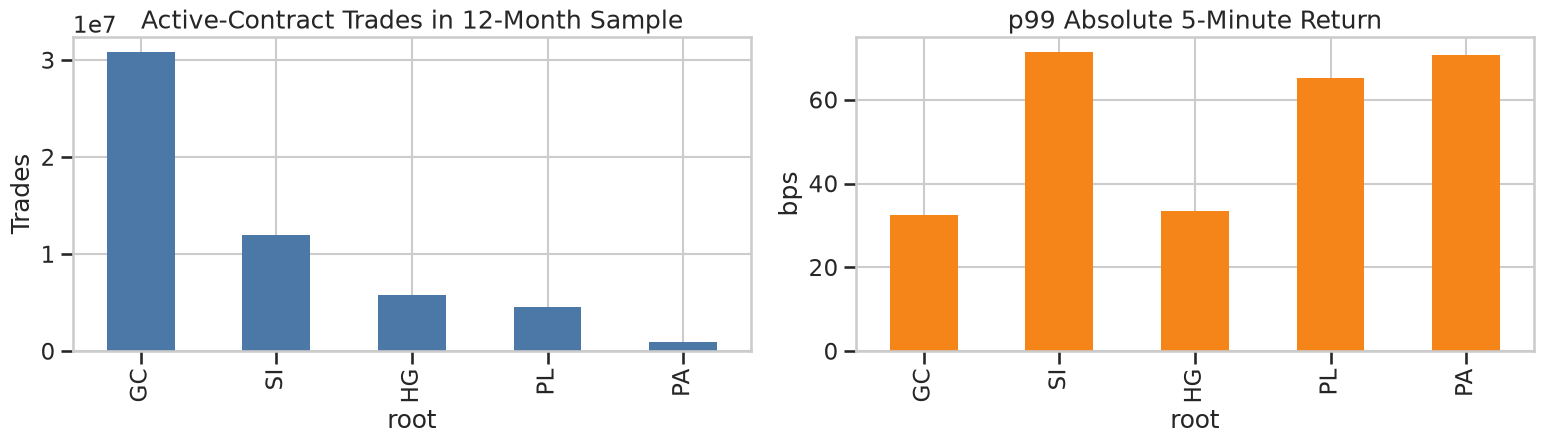

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bar_summary.set_index("root")["total_trades"].plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Active-Contract Trades in 12-Month Sample")
axes[0].set_ylabel("Trades")
bar_summary.set_index("root")["p99_abs_5m_ret_bps"].plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("p99 Absolute 5-Minute Return")
axes[1].set_ylabel("bps")
plt.tight_layout()

## Strategy 1: Extreme Flow Impact Decay

Event definition:

- Build 5-minute active-contract bars.
- Compute signed OFI as buy-aggressor size minus sell-aggressor size.
- Trigger when current signed flow and current return have the same sign.
- Sweep rolling flow percentile, rolling return percentile, direction, and holding horizon.
- Charge one full round-trip cost per event.

The portfolio-level goal is at least one event per day and gross profit at least 3x costs.

In [6]:
def add_flow_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for flow_col in ["ofi", "ofi_q95", "ofi_q99"]:
        ratio_col = f"{flow_col}_ratio"
        rank_col = f"{flow_col}_rank"
        df[ratio_col] = (df[flow_col] / df["volume"].replace(0, np.nan)).fillna(0.0)
        df[rank_col] = df[ratio_col].abs().rolling(LOOKBACK_5M_BARS, min_periods=500).rank(pct=True)
    df["ret_rank"] = df["ret"].abs().rolling(LOOKBACK_5M_BARS, min_periods=500).rank(pct=True)
    return df


feature_bars = {root: add_flow_features(df) for root, df in bars_by_root.items()}

In [7]:
def scan_extreme_flow(feature_bars: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    flow_specs = [
        ("ofi_ratio", "ofi_rank", "ofi"),
        ("ofi_q95_ratio", "ofi_q95_rank", "ofi_q95"),
        ("ofi_q99_ratio", "ofi_q99_rank", "ofi_q99"),
    ]
    for flow_col, rank_col, signed_col in flow_specs:
        for flow_q in [0.80, 0.90, 0.95, 0.98]:
            for ret_q in [0.50, 0.70, 0.80, 0.90]:
                for side, mult in [("fade", -1), ("continue", 1)]:
                    for horizon in HORIZONS_5M:
                        trade_frames = []
                        for root, df in feature_bars.items():
                            event = (
                                df["active_session"]
                                & (df[rank_col] >= flow_q)
                                & (df["ret_rank"] >= ret_q)
                                & (df[signed_col] != 0)
                                & (df["ret"] != 0)
                                & (np.sign(df[signed_col]) == np.sign(df["ret"]))
                            )
                            future = (
                                df["ret"].shift(-1).rolling(horizon).sum().shift(-(horizon - 1))
                            )
                            pnl = (mult * np.sign(df["ret"]) * future)[event].dropna()
                            if len(pnl):
                                trade_frames.append(
                                    pd.DataFrame(
                                        {
                                            "root": root,
                                            "ts": pnl.index,
                                            "pnl": pnl.values,
                                            "cost": ROUND_TRIP_COST_BPS[root] / 10_000,
                                        }
                                    )
                                )
                        if not trade_frames:
                            continue
                        trades = pd.concat(trade_frames, ignore_index=True)
                        gross = trades["pnl"].sum()
                        cost = trades["cost"].sum()
                        rows.append(
                            {
                                "flow": flow_col,
                                "flow_q": flow_q,
                                "ret_q": ret_q,
                                "side": side,
                                "horizon_5m": horizon,
                                "events": len(trades),
                                "events_per_day": len(trades) / DAYS_PER_SAMPLE,
                                "gross_log": gross,
                                "cost_log": cost,
                                "net_log": gross - cost,
                                "gross_cost_x": gross / cost if cost else np.nan,
                                "avg_net_bps": ((trades["pnl"] - trades["cost"]).mean() * 10_000),
                                "win_rate": (trades["pnl"] > 0).mean(),
                                "t_stat": trades["pnl"].mean()
                                / trades["pnl"].std(ddof=1)
                                * np.sqrt(len(trades))
                                if trades["pnl"].std(ddof=1) > 0
                                else np.nan,
                            }
                        )
    return pd.DataFrame(rows)


s1 = scan_extreme_flow(feature_bars)
s1_candidates = s1[(s1["events_per_day"] >= 1.0)].sort_values(
    ["net_log", "gross_cost_x"], ascending=False
)
s1_candidates.head(20)

,flow,flow_q,ret_q,side,horizon_5m,events,events_per_day,gross_log,cost_log,net_log,gross_cost_x,avg_net_bps,win_rate,t_stat
94,ofi_ratio,0.95,0.7,fade,24,3313,9.076712,1.415960,1.1197,0.296260,1.264589,0.894236,0.527317,3.541596
104,ofi_ratio,0.95,0.8,fade,24,1991,5.454795,0.957419,0.6640,0.293419,1.441896,1.473728,0.535409,2.890304
114,ofi_ratio,0.95,0.9,fade,24,802,2.197260,0.552785,0.2629,0.289885,2.102643,3.614525,0.552369,2.407683
74,ofi_ratio,0.90,0.9,fade,24,2400,6.575342,0.993743,0.8224,0.171343,1.208345,0.713930,0.527083,2.392333
103,ofi_ratio,0.95,0.8,fade,12,1991,5.454795,0.775113,0.6640,0.111113,1.167339,0.558078,0.542943,3.296854
464,ofi_q99_ratio,0.98,0.8,fade,24,1063,2.912329,0.514129,0.4204,0.093729,1.222953,0.881744,0.511759,2.139077
113,ofi_ratio,0.95,0.9,fade,12,802,2.197260,0.348462,0.2629,0.085562,1.325453,1.066852,0.547382,2.219236
144,ofi_ratio,0.98,0.8,fade,24,481,1.317808,0.180313,0.1555,0.024813,1.159568,0.515858,0.521830,1.063298
143,ofi_ratio,0.98,0.8,fade,12,481,1.317808,0.157557,0.1555,0.002057,1.013230,0.042772,0.540541,1.229205
313,ofi_q95_ratio,0.98,0.9,fade,12,437,1.197260,0.105586,0.1624,-0.056814,0.650162,-1.300084,0.521739,0.960980


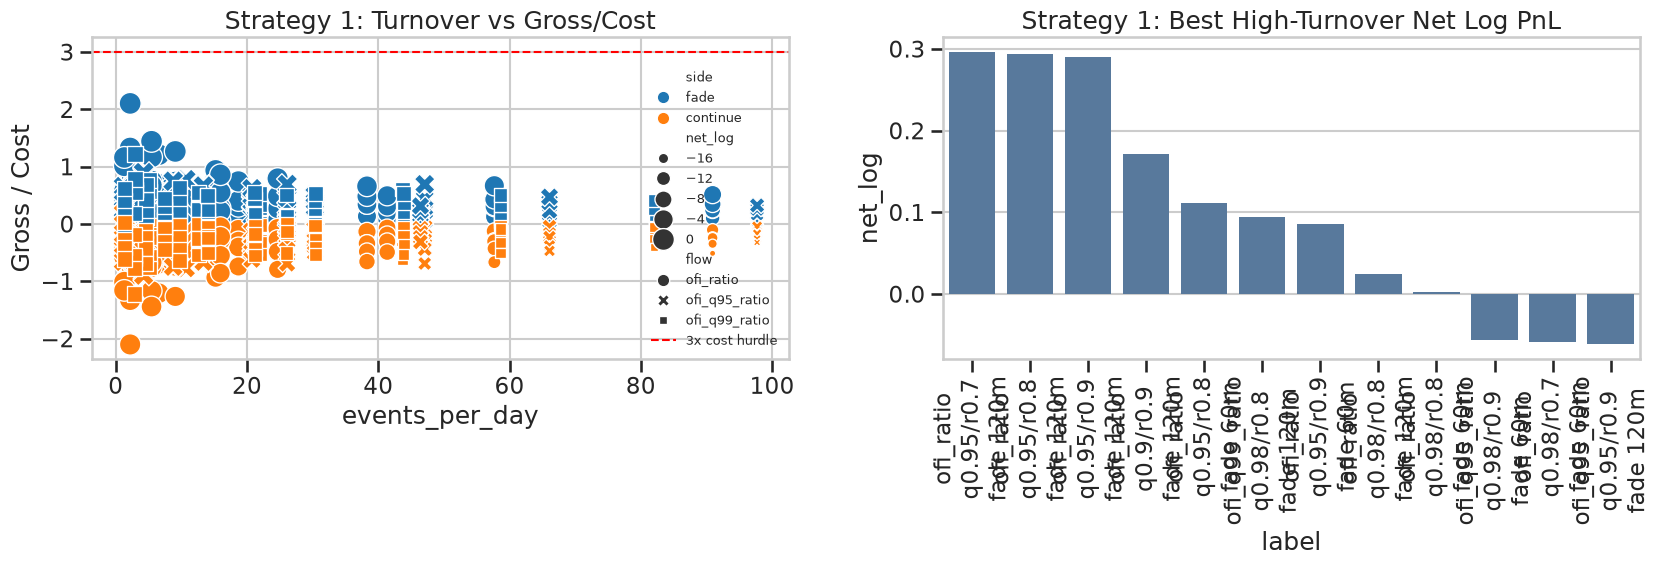

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
plot_df = s1[s1["events_per_day"] >= 1].copy()
sns.scatterplot(
    data=plot_df,
    x="events_per_day",
    y="gross_cost_x",
    hue="side",
    style="flow",
    size="net_log",
    sizes=(20, 250),
    ax=axes[0],
)
axes[0].axhline(3, color="red", linestyle="--", linewidth=1.5, label="3x cost hurdle")
axes[0].set_title("Strategy 1: Turnover vs Gross/Cost")
axes[0].set_ylabel("Gross / Cost")
axes[0].legend(loc="best", fontsize=9)

top_s1 = s1_candidates.head(12).copy()
top_s1["label"] = top_s1.apply(
    lambda r: f"{r.flow}\nq{r.flow_q}/r{r.ret_q}\n{r.side} {int(r.horizon_5m*5)}m", axis=1
)
sns.barplot(data=top_s1, x="label", y="net_log", ax=axes[1], color="#4C78A8")
axes[1].set_title("Strategy 1: Best High-Turnover Net Log PnL")
axes[1].tick_params(axis="x", rotation=90)
plt.tight_layout()

In [9]:
def extreme_flow_trades(row: pd.Series) -> pd.DataFrame:
    signed_col = row["flow"].replace("_ratio", "")
    rank_col = f"{signed_col}_rank"
    mult = -1 if row["side"] == "fade" else 1
    horizon = int(row["horizon_5m"])
    frames = []
    for root, df in feature_bars.items():
        event = (
            df["active_session"]
            & (df[rank_col] >= row["flow_q"])
            & (df["ret_rank"] >= row["ret_q"])
            & (df[signed_col] != 0)
            & (df["ret"] != 0)
            & (np.sign(df[signed_col]) == np.sign(df["ret"]))
        )
        future = df["ret"].shift(-1).rolling(horizon).sum().shift(-(horizon - 1))
        pnl = (mult * np.sign(df["ret"]) * future)[event].dropna()
        if len(pnl):
            frames.append(
                pd.DataFrame(
                    {
                        "root": root,
                        "ts": pnl.index,
                        "gross": pnl.values,
                        "cost": ROUND_TRIP_COST_BPS[root] / 10_000,
                    }
                )
            )
    trades = pd.concat(frames, ignore_index=True).sort_values("ts")
    trades["net"] = trades["gross"] - trades["cost"]
    trades["cum_net"] = trades["net"].cumsum()
    return trades


best_s1 = s1_candidates.iloc[0]
s1_trades = extreme_flow_trades(best_s1)
best_s1.to_frame("value")

,value
flow,ofi_ratio
flow_q,0.95
ret_q,0.7
side,fade
horizon_5m,24
events,3313
events_per_day,9.076712
gross_log,1.41596
cost_log,1.1197
net_log,0.29626


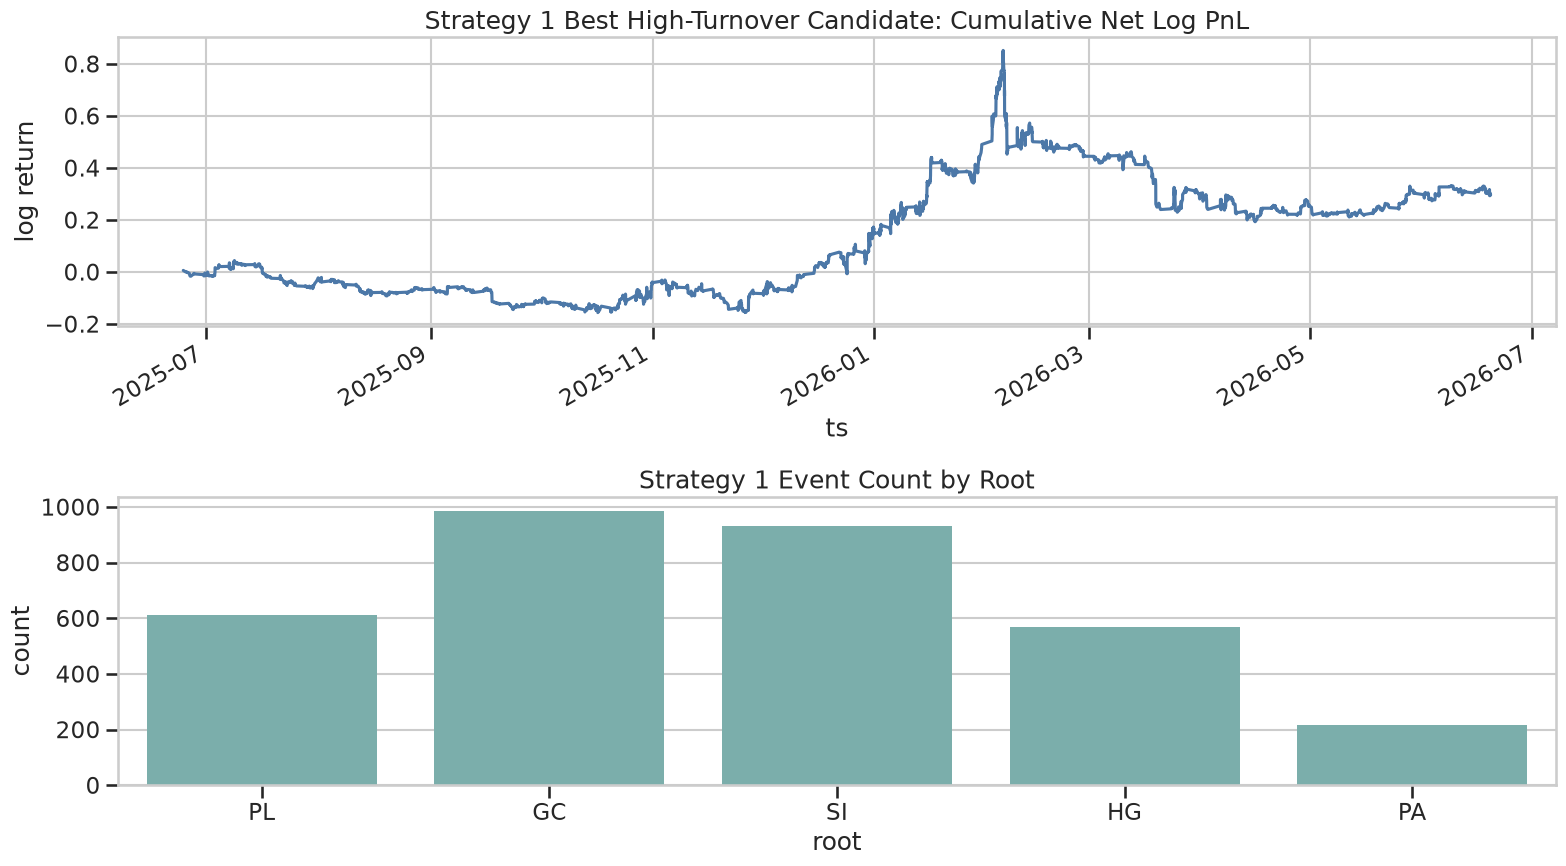

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
s1_trades.set_index("ts")["cum_net"].plot(ax=axes[0], color="#4C78A8")
axes[0].set_title("Strategy 1 Best High-Turnover Candidate: Cumulative Net Log PnL")
axes[0].set_ylabel("log return")
sns.countplot(data=s1_trades, x="root", ax=axes[1], color="#72B7B2")
axes[1].set_title("Strategy 1 Event Count by Root")
plt.tight_layout()

## Strategy 4: Session Window Flow Reversal

Event definition:

- For each root and window, compute window return and window OFI ratio.
- Require signed flow and window return to point in the same direction.
- Fade that window move after the window closes.
- Sweep flow percentile, return percentile, and holding horizon.

This version naturally trades less frequently than per-bar flow signals, but it is more stable because it aggregates pressure over recognizable liquidity windows.

In [11]:
def prepare_session_windows(bars_by_root: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for root, df in bars_by_root.items():
        for window_name, start_minute, end_minute in WINDOWS:
            window_df = df[(df["minute"] >= start_minute) & (df["minute"] < end_minute)]
            if window_df.empty:
                continue
            daily = (
                window_df.groupby("date")[["ret", "ofi", "ofi_q95", "volume"]]
                .sum()
                .rename(columns={"ret": "window_ret"})
            )
            daily["ofi_ratio"] = daily["ofi"] / daily["volume"].replace(0, np.nan)
            daily["ofi_q95_ratio"] = daily["ofi_q95"] / daily["volume"].replace(0, np.nan)
            daily = daily.replace([np.inf, -np.inf], np.nan).dropna()
            if len(daily) < 80:
                continue
            daily["flow_rank"] = daily["ofi_ratio"].abs().rolling(60, min_periods=30).rank(pct=True)
            daily["flow_q95_rank"] = (
                daily["ofi_q95_ratio"].abs().rolling(60, min_periods=30).rank(pct=True)
            )
            daily["ret_rank"] = daily["window_ret"].abs().rolling(60, min_periods=30).rank(pct=True)

            idx_by_date = {d: g.index for d, g in df.groupby("date", sort=False)}
            entry_locs = []
            for date_key in daily.index:
                day_idx = idx_by_date.get(date_key)
                loc = np.nan
                if day_idx is not None:
                    after = df.loc[day_idx]
                    after = after[after["minute"] >= end_minute]
                    if not after.empty:
                        loc = df.index.get_loc(after.index[0])
                        if isinstance(loc, slice):
                            loc = loc.start
                entry_locs.append(loc)
            daily["entry_loc"] = entry_locs
            daily = daily.dropna(subset=["entry_loc"]).copy()
            daily["entry_loc"] = daily["entry_loc"].astype(int)

            ret_values = df["ret"].values
            index_values = df.index
            for horizon in HORIZONS_5M:
                daily[f"fut_{horizon}"] = [
                    np.nan
                    if loc + horizon >= len(ret_values)
                    else ret_values[loc + 1 : loc + horizon + 1].sum()
                    for loc in daily["entry_loc"].values
                ]
            daily["entry_ts"] = [index_values[loc] for loc in daily["entry_loc"].values]
            daily["root"] = root
            daily["window"] = window_name
            daily["cost"] = ROUND_TRIP_COST_BPS[root] / 10_000
            rows.append(daily.reset_index())
    return pd.concat(rows, ignore_index=True)


session_daily = prepare_session_windows(bars_by_root)
session_daily.head()

,date,window_ret,ofi,ofi_q95,volume,ofi_ratio,ofi_q95_ratio,flow_rank,flow_q95_rank,ret_rank,entry_loc,fut_1,fut_3,fut_6,fut_12,fut_24,entry_ts,root,window,cost
0,2025-06-23,-0.004704,-701.0,-1391.0,37946.0,-0.018474,-0.036657,NaN,NaN,NaN,108,0.000208,-0.000297,0.000326,0.002075,0.002697,2025-06-23 07:00:00+00:00,GC,asia_late,0.0003
1,2025-06-24,-0.006392,-247.0,-1280.0,57829.0,-0.004271,-0.022134,NaN,NaN,NaN,396,-0.000779,-0.001049,0.000958,0.001108,0.000180,2025-06-24 07:00:00+00:00,GC,asia_late,0.0003
2,2025-06-25,0.002334,522.0,438.0,23793.0,0.021939,0.018409,NaN,NaN,NaN,684,-0.000209,-0.001197,0.000478,-0.000239,-0.001436,2025-06-25 07:00:00+00:00,GC,asia_late,0.0003
3,2025-06-26,0.000119,-363.0,141.0,26863.0,-0.013513,0.005249,NaN,NaN,NaN,972,0.000358,0.000834,0.001281,0.001281,0.001073,2025-06-26 07:00:00+00:00,GC,asia_late,0.0003
4,2025-06-27,-0.007471,-1331.0,-2046.0,53851.0,-0.024716,-0.037994,NaN,NaN,NaN,1260,-0.000999,-0.001515,-0.001060,-0.001757,-0.001121,2025-06-27 07:00:00+00:00,GC,asia_late,0.0003


In [12]:
def scan_session_reversal(
    session_daily: pd.DataFrame, combine_windows: bool = False
) -> pd.DataFrame:
    rows = []
    flow_specs = [("ofi_ratio", "flow_rank"), ("ofi_q95_ratio", "flow_q95_rank")]
    groups = [None] if combine_windows else sorted(session_daily["window"].unique())
    for group in groups:
        base_df = (
            session_daily if group is None else session_daily[session_daily["window"] == group]
        )
        for flow_col, rank_col in flow_specs:
            for flow_q in [0.50, 0.60, 0.70, 0.80, 0.90]:
                for ret_q in [0.0, 0.50, 0.70]:
                    for horizon in HORIZONS_5M:
                        align = (
                            (np.sign(base_df[flow_col]) == np.sign(base_df["window_ret"]))
                            & (base_df[flow_col] != 0)
                            & (base_df["window_ret"] != 0)
                        )
                        events = base_df[
                            align & (base_df[rank_col] >= flow_q) & (base_df["ret_rank"] >= ret_q)
                        ].copy()
                        if events.empty:
                            continue
                        pnl = -np.sign(events["window_ret"]) * events[f"fut_{horizon}"]
                        pnl = pnl.dropna()
                        events = events.loc[pnl.index]
                        if len(pnl) == 0:
                            continue
                        gross = pnl.sum()
                        cost = events["cost"].sum()
                        rows.append(
                            {
                                "window": "all_windows" if group is None else group,
                                "flow": flow_col,
                                "flow_q": flow_q,
                                "ret_q": ret_q,
                                "horizon_5m": horizon,
                                "events": len(pnl),
                                "events_per_day": len(pnl) / DAYS_PER_SAMPLE,
                                "gross_log": gross,
                                "cost_log": cost,
                                "net_log": gross - cost,
                                "gross_cost_x": gross / cost if cost else np.nan,
                                "avg_net_bps": (
                                    (pnl.values - events["cost"].values).mean() * 10_000
                                ),
                                "win_rate": (pnl > 0).mean(),
                                "t_stat": pnl.mean() / pnl.std(ddof=1) * np.sqrt(len(pnl))
                                if pnl.std(ddof=1) > 0
                                else np.nan,
                            }
                        )
    return pd.DataFrame(rows)


s4_by_window = scan_session_reversal(session_daily, combine_windows=False)
s4_all_windows = scan_session_reversal(session_daily, combine_windows=True)

s4_candidates = s4_by_window[(s4_by_window["events_per_day"] >= 1.0)].sort_values(
    ["net_log", "gross_cost_x"], ascending=False
)
s4_candidates.head(20)

,window,flow,flow_q,ret_q,horizon_5m,events,events_per_day,gross_log,cost_log,net_log,gross_cost_x,avg_net_bps,win_rate,t_stat
1054,us_open_60,ofi_ratio,0.5,0.0,24,366,1.002740,0.574563,0.1390,0.435563,4.133549,11.900638,0.562842,2.633521
1129,us_open_60,ofi_q95_ratio,0.5,0.0,24,390,1.068493,0.439040,0.1456,0.293440,3.015386,7.524109,0.551282,2.168574
1053,us_open_60,ofi_ratio,0.5,0.0,12,366,1.002740,0.357420,0.1390,0.218420,2.571370,5.967772,0.573770,2.210354
829,us_midday,ofi_q95_ratio,0.5,0.0,24,403,1.104110,0.368058,0.1499,0.218158,2.455355,5.413344,0.550868,2.988764
1128,us_open_60,ofi_q95_ratio,0.5,0.0,12,390,1.068493,0.256225,0.1456,0.110625,1.759785,2.836529,0.535897,1.634837
1051,us_open_60,ofi_ratio,0.5,0.0,3,366,1.002740,0.245891,0.1390,0.106891,1.768998,2.920513,0.551913,2.414544
1126,us_open_60,ofi_q95_ratio,0.5,0.0,3,390,1.068493,0.234533,0.1456,0.088933,1.610804,2.280335,0.538462,2.532048
828,us_midday,ofi_q95_ratio,0.5,0.0,12,403,1.104110,0.161671,0.1499,0.011771,1.078529,0.292096,0.528536,1.881643
1127,us_open_60,ofi_q95_ratio,0.5,0.0,6,390,1.068493,0.156356,0.1456,0.010756,1.073876,0.275802,0.533333,1.446059
979,us_open_30,ofi_q95_ratio,0.5,0.0,24,398,1.090411,0.149341,0.1474,0.001941,1.013166,0.048762,0.517588,0.666238


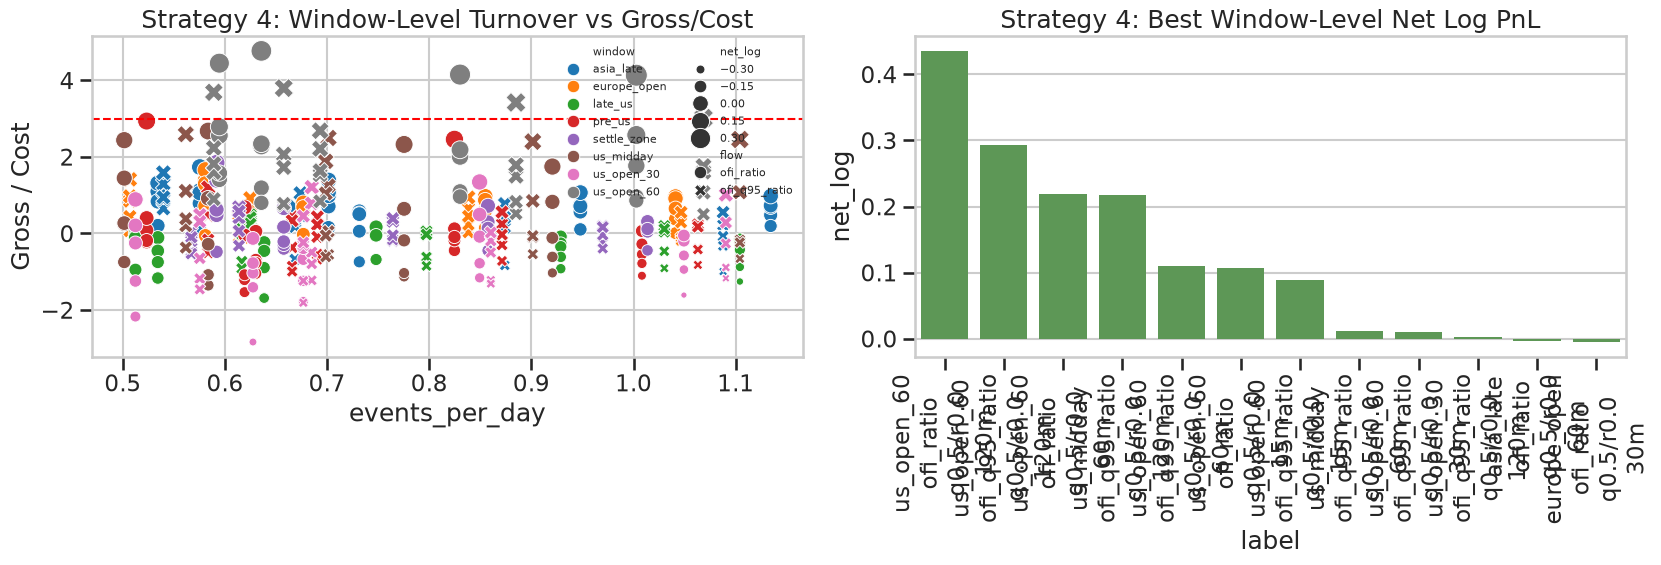

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
plot_df = s4_by_window[s4_by_window["events_per_day"] >= 0.5].copy()
sns.scatterplot(
    data=plot_df,
    x="events_per_day",
    y="gross_cost_x",
    hue="window",
    style="flow",
    size="net_log",
    sizes=(20, 250),
    ax=axes[0],
)
axes[0].axhline(3, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Strategy 4: Window-Level Turnover vs Gross/Cost")
axes[0].set_ylabel("Gross / Cost")
axes[0].legend(loc="best", fontsize=8, ncols=2)

top_s4 = s4_candidates.head(12).copy()
top_s4["label"] = top_s4.apply(
    lambda r: f"{r.window}\n{r.flow}\nq{r.flow_q}/r{r.ret_q}\n{int(r.horizon_5m*5)}m", axis=1
)
sns.barplot(data=top_s4, x="label", y="net_log", ax=axes[1], color="#54A24B")
axes[1].set_title("Strategy 4: Best Window-Level Net Log PnL")
axes[1].tick_params(axis="x", rotation=90)
plt.tight_layout()

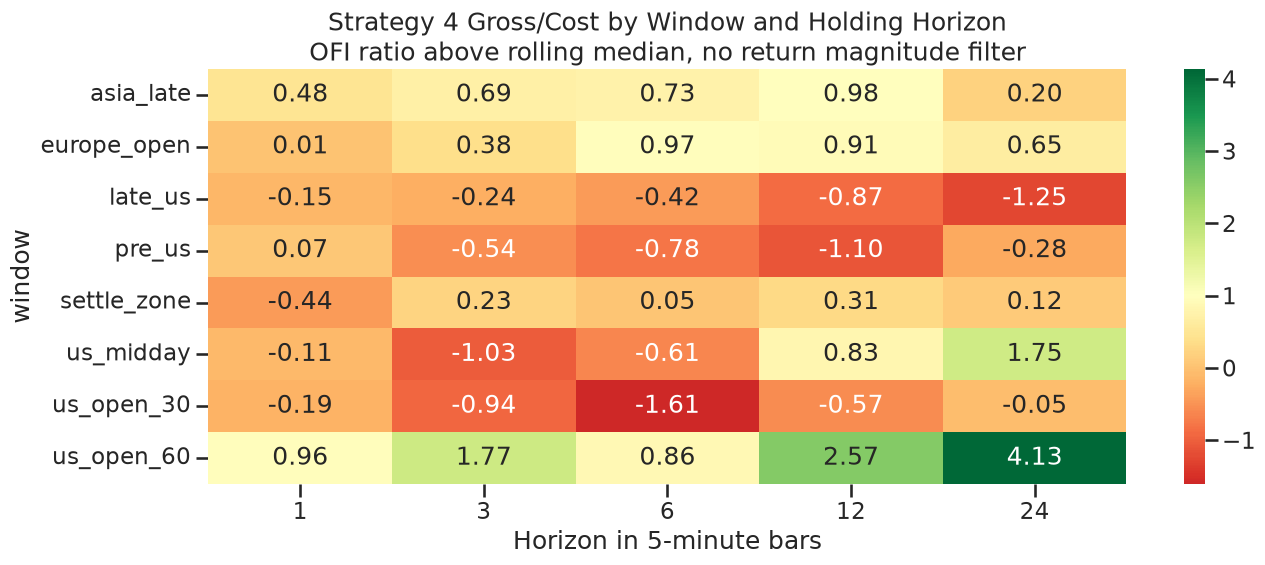

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
heat = s4_by_window[
    (s4_by_window["flow"] == "ofi_ratio")
    & (s4_by_window["flow_q"] == 0.50)
    & (s4_by_window["ret_q"] == 0.0)
]
heat = heat.pivot_table(index="window", columns="horizon_5m", values="gross_cost_x", aggfunc="max")
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0, ax=ax)
ax.set_title(
    "Strategy 4 Gross/Cost by Window and Holding Horizon\nOFI ratio above rolling median, no return magnitude filter"
)
ax.set_xlabel("Horizon in 5-minute bars")
plt.tight_layout()

In [15]:
def session_reversal_trades(row: pd.Series) -> pd.DataFrame:
    rank_col = "flow_rank" if row["flow"] == "ofi_ratio" else "flow_q95_rank"
    df = session_daily[session_daily["window"] == row["window"]].copy()
    align = (
        (np.sign(df[row["flow"]]) == np.sign(df["window_ret"]))
        & (df[row["flow"]] != 0)
        & (df["window_ret"] != 0)
    )
    events = df[align & (df[rank_col] >= row["flow_q"]) & (df["ret_rank"] >= row["ret_q"])].copy()
    pnl = -np.sign(events["window_ret"]) * events[f"fut_{int(row['horizon_5m'])}"]
    pnl = pnl.dropna()
    events = events.loc[pnl.index].copy()
    events["gross"] = pnl.values
    events["net"] = events["gross"] - events["cost"]
    events = events.sort_values("entry_ts")
    events["cum_net"] = events["net"].cumsum()
    return events


best_s4 = s4_candidates.iloc[0]
s4_trades = session_reversal_trades(best_s4)
best_s4.to_frame("value")

,value
window,us_open_60
flow,ofi_ratio
flow_q,0.5
ret_q,0.0
horizon_5m,24
events,366
events_per_day,1.00274
gross_log,0.574563
cost_log,0.139
net_log,0.435563


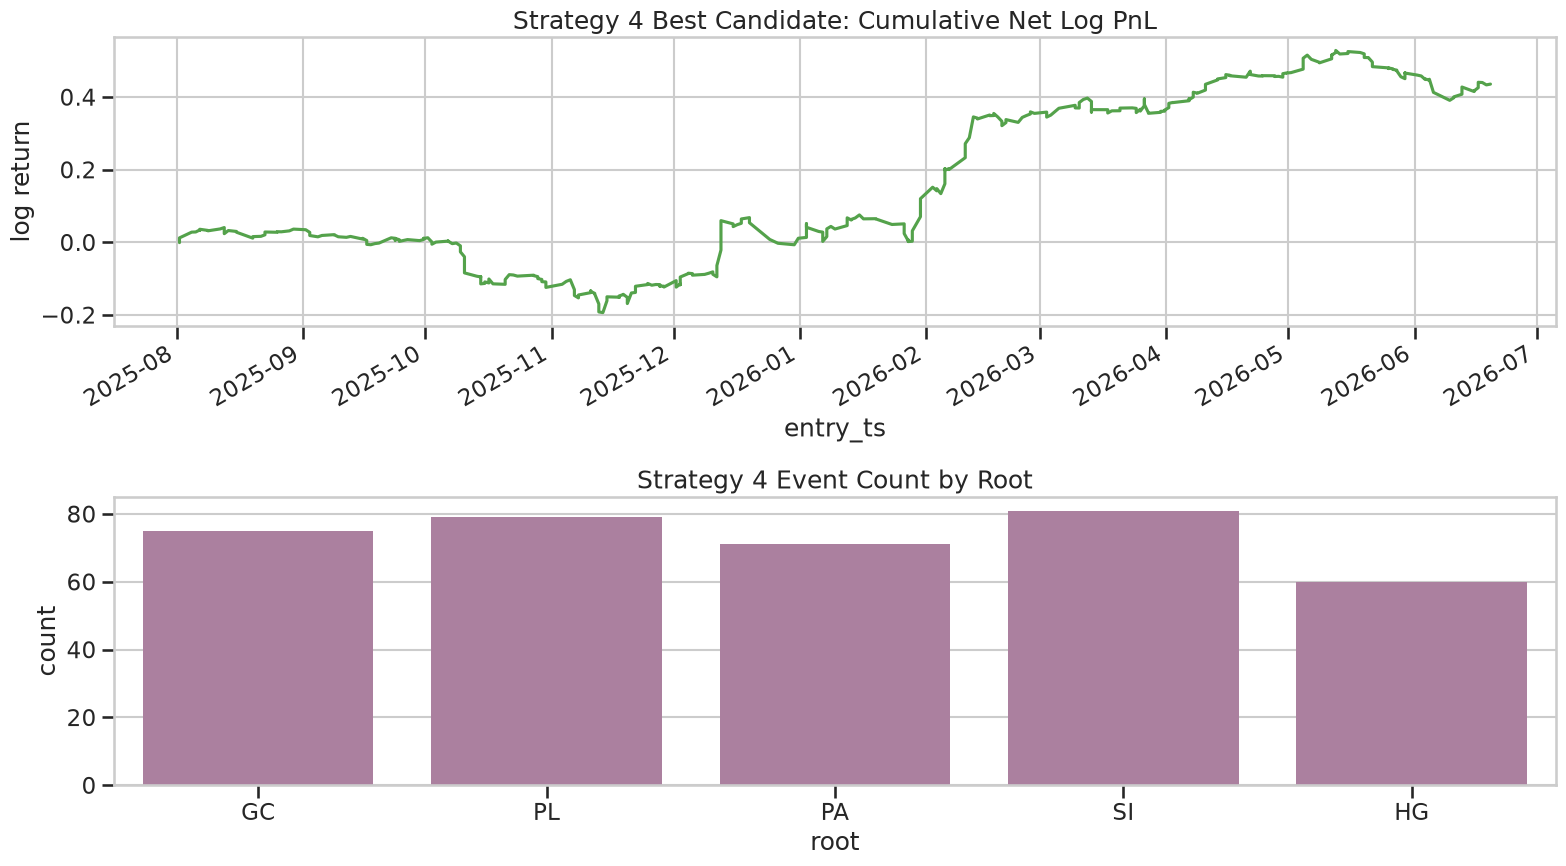

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
s4_trades.set_index("entry_ts")["cum_net"].plot(ax=axes[0], color="#54A24B")
axes[0].set_title("Strategy 4 Best Candidate: Cumulative Net Log PnL")
axes[0].set_ylabel("log return")
sns.countplot(data=s4_trades, x="root", ax=axes[1], color="#B279A2")
axes[1].set_title("Strategy 4 Event Count by Root")
plt.tight_layout()

In [17]:
combined_candidates = s4_all_windows[s4_all_windows["events_per_day"] >= 1.0].sort_values(
    ["net_log", "gross_cost_x"], ascending=False
)
combined_candidates.head(15)

,window,flow,flow_q,ret_q,horizon_5m,events,events_per_day,gross_log,cost_log,net_log,gross_cost_x,avg_net_bps,win_rate,t_stat
29,all_windows,ofi_ratio,0.6,0.7,24,956,2.619178,0.804468,0.3612,0.443268,2.227210,4.636697,0.533473,2.405423
24,all_windows,ofi_ratio,0.6,0.5,24,1472,4.032877,0.954860,0.5584,0.396460,1.709992,2.693340,0.521739,2.459070
44,all_windows,ofi_ratio,0.7,0.7,24,743,2.035616,0.636612,0.2785,0.358112,2.285860,4.819813,0.542396,2.146238
69,all_windows,ofi_ratio,0.9,0.5,24,453,1.241096,0.513050,0.1733,0.339750,2.960476,7.500009,0.527594,2.327498
59,all_windows,ofi_ratio,0.8,0.7,24,519,1.421918,0.519330,0.1955,0.323830,2.656420,6.239503,0.549133,1.995624
54,all_windows,ofi_ratio,0.8,0.5,24,812,2.224658,0.588588,0.3087,0.279888,1.906667,3.446898,0.524631,2.005868
39,all_windows,ofi_ratio,0.7,0.5,24,1153,3.158904,0.693217,0.4368,0.256417,1.587036,2.223914,0.529055,2.045396
134,all_windows,ofi_q95_ratio,0.8,0.7,24,582,1.594521,0.464197,0.2100,0.254197,2.210462,4.367647,0.554983,1.909063
19,all_windows,ofi_ratio,0.6,0.0,24,2507,6.868493,1.184806,0.9524,0.232406,1.244022,0.927029,0.507379,2.603798
58,all_windows,ofi_ratio,0.8,0.7,12,519,1.421918,0.397362,0.1955,0.201862,2.032541,3.889436,0.574181,2.303726


## Readout

- **Extreme Flow Impact Decay** has a detectable gross fade effect, especially at longer horizons, but the high-turnover portfolio versions do **not** meet the 3x gross/cost hurdle in this sample. The best one-event-plus-per-day variants are net positive but sit well below 3x costs.
- **Session Window Flow Reversal** is stronger when it is localized. The best candidate is the **US first 60 minutes**: when window OFI and price move in the same direction and absolute OFI is above its rolling 60-day median, fade the move for 24 five-minute bars, or roughly two hours. This trades about once per day and clears the 3x hurdle in this 12-month sample.
- Combining all windows increases turnover to several events per day, but it dilutes edge and falls below 3x costs. The signal is window-specific rather than universal.
- The results are still exploratory: costs are bps approximations, fills assume bar-close/next-bar execution, and the sample is only 12 months of trade data. The next production-quality test should use contract-specific tick values, bid/ask or MBP slippage, walk-forward parameter selection, and an explicit position-overlap model.